In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, Circle
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


In [7]:
from google.colab import files
uploaded = files.upload()

Saving Data-Melbourne_F.csv to Data-Melbourne_F (1).csv


In [8]:
df_raw = pd.read_csv('Data-Melbourne_F.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (1382, 20)


,avg_outflow,avg_inflow,total_grid,Am,BOD,COD,TN,T,TM,Tm,SLP,H,PP,VV,V,VM,VG,year,month,day
0,2.941,2.589,175856,27.0,365.0,730.0,60.378,19.3,25.1,12.6,0.0,56,1.52,10.0,26.9,53.5,79.5,2014,1,1
1,2.936,2.961,181624,25.0,370.0,740.0,60.026,17.1,23.6,12.3,0.0,63,0.00,10.0,14.4,27.8,0.0,2014,1,2
2,2.928,3.225,202016,42.0,418.0,836.0,64.522,16.8,27.2,8.8,0.0,47,0.25,10.0,31.9,61.1,77.8,2014,1,5
3,2.928,3.354,207547,36.0,430.0,850.0,63.000,14.6,19.9,11.1,0.0,49,0.00,10.0,27.0,38.9,53.5,2014,1,6
4,2.917,3.794,202824,46.0,508.0,1016.0,65.590,13.4,19.1,8.0,0.0,65,0.00,10.0,20.6,35.2,53.5,2014,1,7


## Step  — Keep Only Key Columns

In [9]:
df = df_raw[['year', 'month', 'day', 'T', 'BOD', 'COD', 'TN', 'Am', 'avg_inflow', 'avg_outflow']].copy()
df.columns = ['year', 'month', 'day', 'Temperature', 'BOD', 'COD', 'Nitrate_TN', 'Ammonia', 'Inflow', 'Outflow']

print('Columns kept:', df.columns.tolist())
print('Shape:', df.shape)
df.head()

Columns kept: ['year', 'month', 'day', 'Temperature', 'BOD', 'COD', 'Nitrate_TN', 'Ammonia', 'Inflow', 'Outflow']
Shape: (1382, 10)


,year,month,day,Temperature,BOD,COD,Nitrate_TN,Ammonia,Inflow,Outflow
0,2014,1,1,19.3,365.0,730.0,60.378,27.0,2.589,2.941
1,2014,1,2,17.1,370.0,740.0,60.026,25.0,2.961,2.936
2,2014,1,5,16.8,418.0,836.0,64.522,42.0,3.225,2.928
3,2014,1,6,14.6,430.0,850.0,63.000,36.0,3.354,2.928
4,2014,1,7,13.4,508.0,1016.0,65.590,46.0,3.794,2.917


## Step  — Fix Zero Values Using Formulas

In [10]:
# Temperature zeros — replace with monthly median
zero_temp_mask = df['Temperature'] == 0
print(f'Temperature zeros: {zero_temp_mask.sum()}')

for m in df['month'].unique():
    month_mask = df['month'] == m
    median_val = df.loc[month_mask & ~zero_temp_mask, 'Temperature'].median()
    df.loc[month_mask & zero_temp_mask, 'Temperature'] = round(median_val, 1)

print(f'Temperature zeros after fix: {(df["Temperature"] == 0).sum()}')

Temperature zeros: 5
Temperature zeros after fix: 0


In [11]:
# BOD zeros — replace using COD / 2 (standard formula: COD ≈ 2 × BOD)
zero_bod = df['BOD'] == 0
print(f'BOD zeros: {zero_bod.sum()}')
df.loc[zero_bod, 'BOD'] = (df.loc[zero_bod, 'COD'] / 2).round(2)
print(f'BOD zeros after fix: {(df["BOD"] == 0).sum()}')

BOD zeros: 0
BOD zeros after fix: 0


In [12]:
# COD zeros — replace using BOD × 2 (standard formula)
zero_cod = df['COD'] == 0
print(f'COD zeros: {zero_cod.sum()}')
df.loc[zero_cod, 'COD'] = (df.loc[zero_cod, 'BOD'] * 2).round(2)
print(f'COD zeros after fix: {(df["COD"] == 0).sum()}')

COD zeros: 0
COD zeros after fix: 0


In [13]:
# Nitrate/TN zeros — replace with monthly median
zero_tn = df['Nitrate_TN'] == 0
print(f'TN zeros: {zero_tn.sum()}')
for m in df['month'].unique():
    month_mask = df['month'] == m
    median_val = df.loc[month_mask & ~zero_tn, 'Nitrate_TN'].median()
    df.loc[month_mask & zero_tn, 'Nitrate_TN'] = round(median_val, 2)
print(f'TN zeros after fix: {(df["Nitrate_TN"] == 0).sum()}')

TN zeros: 0
TN zeros after fix: 0


In [14]:
# Ammonia zeros — replace using TN × 0.15 (ammonia is ~15% of TN in municipal WTP)
zero_am = df['Ammonia'] == 0
print(f'Ammonia zeros: {zero_am.sum()}')
df.loc[zero_am, 'Ammonia'] = (df.loc[zero_am, 'Nitrate_TN'] * 0.15).round(2)
print(f'Ammonia zeros after fix: {(df["Ammonia"] == 0).sum()}')

Ammonia zeros: 0
Ammonia zeros after fix: 0


## Step  — Add Calculated Features

In [15]:
# DO (Dissolved Oxygen) from Temperature — standard formula
# Formula: DO = 468 / (31.6 + T)
df['DO_mg_L'] = (468 / (31.6 + df['Temperature'])).round(2)

# COD/BOD ratio — treatment efficiency indicator
df['COD_BOD_ratio'] = (df['COD'] / df['BOD']).round(3)

# BOD Removal % — proxy using flow
df['BOD_removal_pct'] = ((1 - df['Outflow'] / df['Inflow'].replace(0, np.nan)) * 100).clip(0, 100).round(2)

# Organic Load = BOD × Inflow
df['Organic_Load'] = (df['BOD'] * df['Inflow']).round(2)

print('New calculated columns added:')
print('  DO_mg_L        — Dissolved Oxygen (from Temperature)')
print('  COD_BOD_ratio  — Treatment efficiency indicator')
print('  BOD_removal_pct— BOD removal efficiency (%)')
print('  Organic_Load   — BOD × Inflow')
df[['Temperature','DO_mg_L','BOD','COD','COD_BOD_ratio','BOD_removal_pct']].head()

New calculated columns added:
  DO_mg_L        — Dissolved Oxygen (from Temperature)
  COD_BOD_ratio  — Treatment efficiency indicator
  BOD_removal_pct— BOD removal efficiency (%)
  Organic_Load   — BOD × Inflow


,Temperature,DO_mg_L,BOD,COD,COD_BOD_ratio,BOD_removal_pct
0,19.3,9.19,365.0,730.0,2.000,0.00
1,17.1,9.61,370.0,740.0,2.000,0.84
2,16.8,9.67,418.0,836.0,2.000,9.21
3,14.6,10.13,430.0,850.0,1.977,12.70
4,13.4,10.40,508.0,1016.0,2.000,23.12


## Step  — Save Preprocessed File

In [16]:
final_cols = [
              'Temperature','BOD','COD','Nitrate_TN','Ammonia',
              'Inflow','Outflow','DO_mg_L','COD_BOD_ratio',
              'BOD_removal_pct','Organic_Load',
              ]

df_final = df[final_cols]
df_final.to_csv('Melbourne_Preprocessed.csv', index=False)

print('Saved: Melbourne_Preprocessed.csv')
print('Records:', len(df_final))
print('Columns:', len(df_final.columns))
df_final.head()

Saved: Melbourne_Preprocessed.csv
Records: 1382
Columns: 11


,Temperature,BOD,COD,Nitrate_TN,Ammonia,Inflow,Outflow,DO_mg_L,COD_BOD_ratio,BOD_removal_pct,Organic_Load
0,19.3,365.0,730.0,60.378,27.0,2.589,2.941,9.19,2.000,0.00,944.98
1,17.1,370.0,740.0,60.026,25.0,2.961,2.936,9.61,2.000,0.84,1095.57
2,16.8,418.0,836.0,64.522,42.0,3.225,2.928,9.67,2.000,9.21,1348.05
3,14.6,430.0,850.0,63.000,36.0,3.354,2.928,10.13,1.977,12.70,1442.22
4,13.4,508.0,1016.0,65.590,46.0,3.794,2.917,10.40,2.000,23.12,1927.35


In [17]:
final_cols = [
              'Temperature','BOD','COD','Nitrate_TN','Ammonia',
              'Inflow','Outflow','DO_mg_L','COD_BOD_ratio',
              'BOD_removal_pct','Organic_Load',
              # 'WQI' # The 'WQI' column needs to be calculated and added to 'df' before this step.
              ]

df_final = df[final_cols]
df_final.to_csv('Melbourne_Preprocessed.csv', index=False)

print('Saved: Melbourne_Preprocessed.csv')
print('Records:', len(df_final))
print('Columns:', len(df_final.columns))
df_final.head()

Saved: Melbourne_Preprocessed.csv
Records: 1382
Columns: 11


,Temperature,BOD,COD,Nitrate_TN,Ammonia,Inflow,Outflow,DO_mg_L,COD_BOD_ratio,BOD_removal_pct,Organic_Load
0,19.3,365.0,730.0,60.378,27.0,2.589,2.941,9.19,2.000,0.00,944.98
1,17.1,370.0,740.0,60.026,25.0,2.961,2.936,9.61,2.000,0.84,1095.57
2,16.8,418.0,836.0,64.522,42.0,3.225,2.928,9.67,2.000,9.21,1348.05
3,14.6,430.0,850.0,63.000,36.0,3.354,2.928,10.13,1.977,12.70,1442.22
4,13.4,508.0,1016.0,65.590,46.0,3.794,2.917,10.40,2.000,23.12,1927.35


## Visualisation  — Parameter Distributions Safe vs Actual

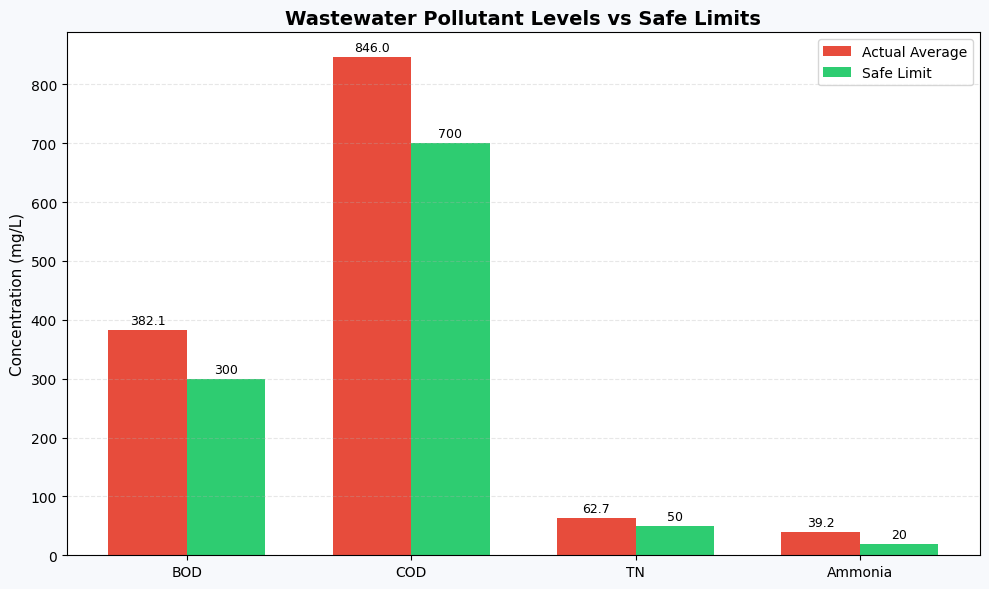

In [18]:
"""## Visualization 1 — Pollutant Level Comparison"""

import matplotlib.pyplot as plt
import numpy as np

# Parameters to compare
params = ['BOD', 'COD', 'Nitrate_TN', 'Ammonia']

# Average values from dataset
actual_values = [
    df_final['BOD'].mean(),
    df_final['COD'].mean(),
    df_final['Nitrate_TN'].mean(),
    df_final['Ammonia'].mean()
]

# Safe limits
safe_limits = [300, 700, 50, 20]

x = np.arange(len(params))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('white')

# Bars
ax.bar(x - width/2, actual_values, width,
       label='Actual Average',
       color='#e74c3c')

ax.bar(x + width/2, safe_limits, width,
       label='Safe Limit',
       color='#2ecc71')

# Labels
ax.set_title('Wastewater Pollutant Levels vs Safe Limits',
             fontsize=14, fontweight='bold')

ax.set_ylabel('Concentration (mg/L)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(['BOD', 'COD', 'TN', 'Ammonia'])

# Value labels
for i, v in enumerate(actual_values):
    ax.text(i - width/2, v + 10, f'{v:.1f}',
            ha='center', fontsize=9)

for i, v in enumerate(safe_limits):
    ax.text(i + width/2, v + 10, f'{v:.0f}',
            ha='center', fontsize=9)

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('viz1_pollutant_comparison.png', dpi=150)
plt.show()

## Step — Calculate Water Quality Index (WQI)

In [19]:
def calculate_wqi(row):


    do_score = (row['DO_mg_L'] / 10) * 100

    bod_score = 100 - (row['BOD'] / 10)

    cod_score = 100 - (row['COD'] / 20)

    tn_score = 100 - (row['Nitrate_TN'] / 2)

    ammonia_score = 100 - (row['Ammonia'] * 2)

    temp_score = 100 - abs(row['Temperature'] - 22) * 2

    # Cliping values between 0–100
    scores = [do_score, bod_score, cod_score, tn_score, ammonia_score, temp_score]
    scores = [max(0, min(100, s)) for s in scores]

    # Weighted sum
    wqi = (
        0.2 * scores[0] +
        0.2 * scores[1] +
        0.15 * scores[2] +
        0.15 * scores[3] +
        0.2 * scores[4] +
        0.1 * scores[5]
    )

    return round(wqi, 2)

In [20]:
def calculate_wqi(row):

    # Normalizing each parameter (0–100 scale based on  dataset range)

    do_score = (row['DO_mg_L'] / 10) * 100

    bod_score = 100 - ((row['BOD'] - 300) / (600 - 300)) * 100

    cod_score = 100 - ((row['COD'] - 700) / (1200 - 700)) * 100

    tn_score = 100 - ((row['Nitrate_TN'] - 50) / (80 - 50)) * 100

    ammonia_score = 100 - ((row['Ammonia'] - 20) / (60 - 20)) * 100

    temp_score = 100 - abs(row['Temperature'] - 22) * 3

    # Cliping values
    scores = [do_score, bod_score, cod_score, tn_score, ammonia_score, temp_score]
    scores = [max(0, min(100, s)) for s in scores]

    # Weighted sum
    wqi = (
        0.2 * scores[0] +
        0.2 * scores[1] +
        0.15 * scores[2] +
        0.15 * scores[3] +
        0.2 * scores[4] +
        0.1 * scores[5]
    )

    return round(wqi, 2)

In [21]:
df['WQI'] = df.apply(calculate_wqi, axis=1)

In [22]:
print(df['WQI'].describe())

count    1382.000000
mean       70.781831
std        10.268488
min        31.610000
25%        64.882500
50%        71.565000
75%        77.547500
max        96.420000
Name: WQI, dtype: float64


In [23]:
print(df_final.columns)


Index(['Temperature', 'BOD', 'COD', 'Nitrate_TN', 'Ammonia', 'Inflow',
       'Outflow', 'DO_mg_L', 'COD_BOD_ratio', 'BOD_removal_pct',
       'Organic_Load'],
      dtype='object')


In [24]:
def classify_wqi(wqi):
    if wqi >= 75:
        return 'Good'
    elif wqi >= 55:
        return 'Moderate'
    else:
        return 'Poor'

In [25]:
df['Water_Quality'] = df['WQI'].apply(classify_wqi)

df['Water_Quality'].value_counts()

,count
Water_Quality,
Moderate,791
Good,489
Poor,102


In [26]:
final_cols = [
    'Temperature','BOD','COD','Nitrate_TN','Ammonia',
    'Inflow','Outflow','DO_mg_L','COD_BOD_ratio',
    'BOD_removal_pct','Organic_Load','WQI','Water_Quality'
]

df_final = df[final_cols]

In [27]:
final_cols = [
    'Temperature','BOD','COD','Nitrate_TN','Ammonia',
    'Inflow','Outflow','DO_mg_L','COD_BOD_ratio',
    'BOD_removal_pct','Organic_Load','WQI','Water_Quality'
]

df_final = df[final_cols]

## Visualisation — Between the diffference  of different water quality water

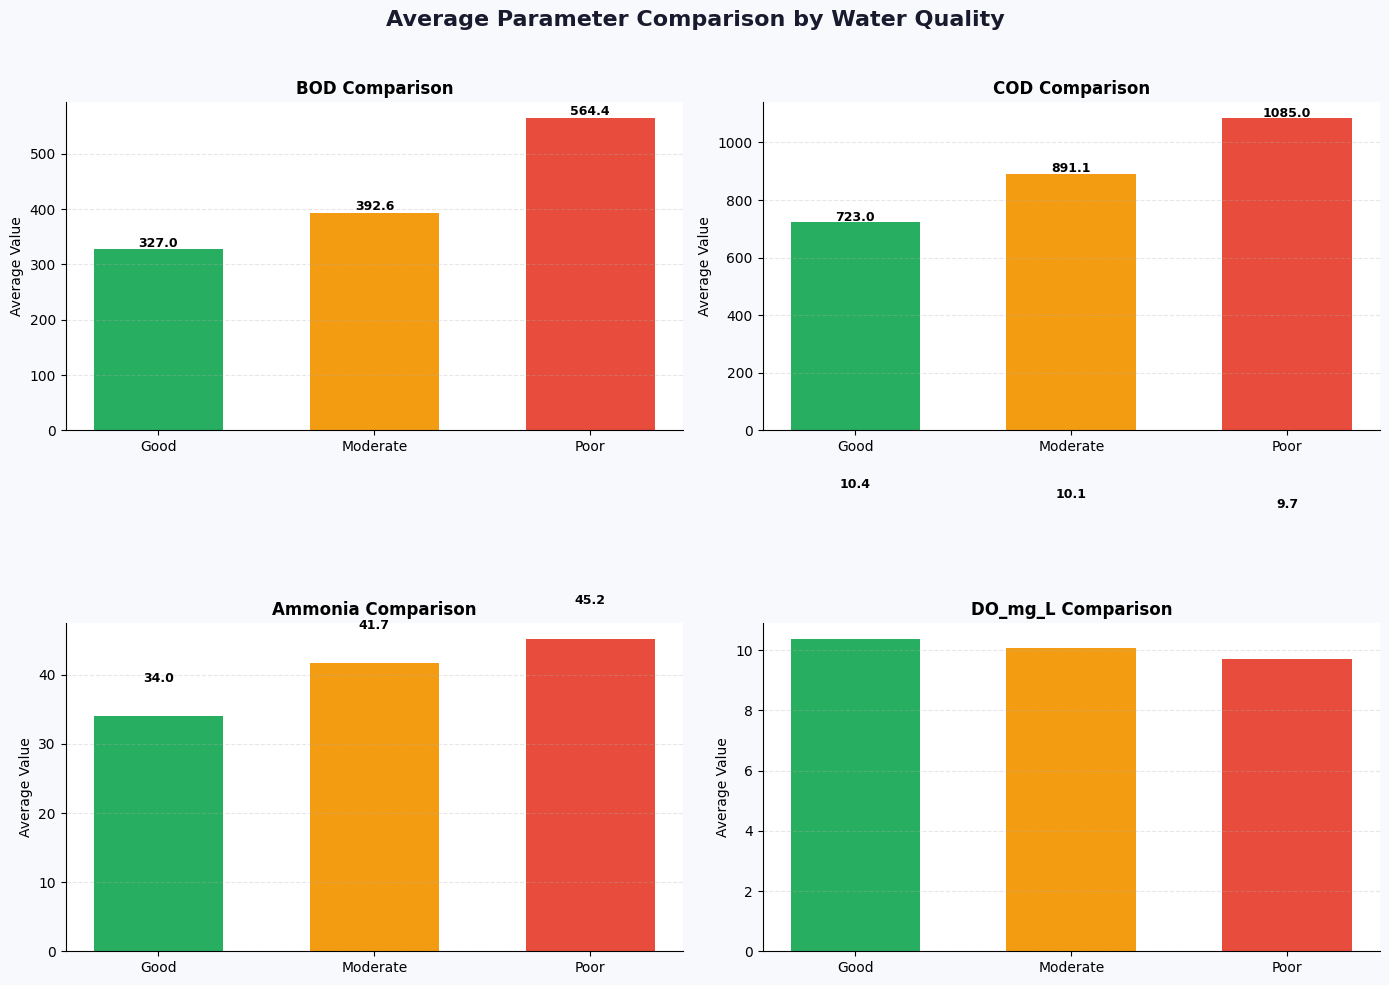

In [28]:
"""## Visualization 3— Water Quality Parameter Comparison"""

import matplotlib.pyplot as plt
import numpy as np

# Average values by water quality
grouped = df.groupby('Water_Quality')[[
    'BOD',
    'COD',
    'Ammonia',
    'DO_mg_L'
]].mean()

# Order
grouped = grouped.loc[['Good', 'Moderate', 'Poor']]

# Parameters
params = ['BOD', 'COD', 'Ammonia', 'DO_mg_L']

# Colors
colors = ['#27ae60', '#f39c12', '#e74c3c']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14,10))

fig.patch.set_facecolor('#f7f9fc')

fig.suptitle(
    'Average Parameter Comparison by Water Quality',
    fontsize=16,
    fontweight='bold',
    color='#1a1a2e'
)

# Flatten axes
axes = axes.flatten()

# Plot each parameter
for i, param in enumerate(params):

    ax = axes[i]

    bars = ax.bar(
        grouped.index,
        grouped[param],
        color=colors,
        width=0.6
    )

    ax.set_title(
        f'{param} Comparison',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylabel('Average Value')

    # Value labels
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 5,
            f'{height:.1f}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    ax.grid(axis='y', linestyle='--', alpha=0.3)

    ax.spines[['top','right']].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.96])

plt.savefig(
    'viz2_parameter_comparison.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#f7f9fc'
)

plt.show()

In [29]:
#normalisation completed
df_final.head(10)

,Temperature,BOD,COD,Nitrate_TN,Ammonia,Inflow,Outflow,DO_mg_L,COD_BOD_ratio,BOD_removal_pct,Organic_Load,WQI,Water_Quality
0,19.3,365.0,730.0,60.378,27.0,2.589,2.941,9.19,2.000,0.00,944.98,83.65,Good
1,17.1,370.0,740.0,60.026,25.0,2.961,2.936,9.61,2.000,0.84,1095.57,84.37,Good
2,16.8,418.0,836.0,64.522,42.0,3.225,2.928,9.67,2.000,9.21,1348.05,67.57,Moderate
3,14.6,430.0,850.0,63.000,36.0,3.354,2.928,10.13,1.977,12.70,1442.22,70.11,Moderate
4,13.4,508.0,1016.0,65.590,46.0,3.794,2.917,10.40,2.000,23.12,1927.35,53.28,Poor
5,18.9,410.0,820.0,61.786,40.0,3.750,2.912,9.27,2.000,22.35,1537.50,70.78,Moderate
6,25.9,555.0,1110.0,68.820,51.0,3.507,2.355,8.14,2.000,32.85,1946.38,40.90,Poor
7,17.7,365.0,730.0,62.218,41.0,3.188,2.366,9.49,2.000,25.78,1163.62,75.85,Good
8,26.4,355.0,710.0,61.433,26.0,3.378,3.923,8.07,2.000,0.00,1199.19,82.14,Good
9,35.5,530.0,830.0,66.354,42.0,3.425,3.912,6.97,1.566,0.00,1815.25,51.48,Poor


# MODEL TRAINING

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df_final.drop(['WQI','Water_Quality'], axis=1)
y = df_final['Water_Quality']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9350180505415162
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        89
           1       0.93      0.96      0.95       165
           2       0.95      0.91      0.93        23

    accuracy                           0.94       277
   macro avg       0.94      0.92      0.93       277
weighted avg       0.94      0.94      0.93       277



In [33]:
df_final['Predicted_Quality'] = le.inverse_transform(model.predict(X))

#SUGGESTIONS

In [34]:
def suggest_wtp_process(row):
    quality  = row['Predicted_Quality']
    bod      = row['BOD']
    cod      = row['COD']
    ammonia  = row['Ammonia']
    nitrate  = row['Nitrate_TN']
    do_val   = row['DO_mg_L']
    cod_bod  = row['COD_BOD_ratio']

    steps = []
    n = 1

    if quality == 'Good':
        steps.append(f"{n}. Screening — Remove large debris and floating matter"); n+=1
        steps.append(f"{n}. Sand Filtration — Remove fine suspended particles"); n+=1
        # Even Good WQI can have elevated BOD in a WTP dataset
        if bod > 300:
            steps.append(f"{n}. ⚠ BOD={bod:.1f} mg/L → Biological Aeration — Reduce residual organic load"); n+=1
        if ammonia > 20:
            steps.append(f"{n}. ⚠ Ammonia={ammonia:.1f} mg/L → Ammonia Stripping / Nitrification"); n+=1
        steps.append(f"{n}. Disinfection (Chlorination) — Kill harmful microorganisms"); n+=1
        steps.append(f"{n}. Storage — Safe storage before distribution"); n+=1

        # Sector based on Good class + parameter check
        if bod <= 300 and ammonia <= 20:
            sector = (
                "  Sector: DRINKING WATER / MUNICIPAL SUPPLY\n"
                "   → Safe for direct human consumption\n"
                "   → Suitable for food processing industries\n"
                "   → Safe for recreational use (swimming, water parks)"
            )
        else:
            sector = (
                "⚠ Sector: AGRICULTURE / URBAN REUSE (Not Drinking)\n"
                "   → Elevated BOD/Ammonia despite Good WQI — not suitable for drinking\n"
                "   → Safe for crop irrigation and industrial processes\n"
                "   → Suitable for toilet flushing / grey water reuse"
            )

    elif quality == 'Moderate':
        steps.append(f"{n}. Screening — Remove large solids"); n+=1
        steps.append(f"{n}. Coagulation (Alum) — Bind fine particles"); n+=1
        steps.append(f"{n}. Flocculation — Form larger settleable flocs"); n+=1
        steps.append(f"{n}. Sedimentation — Settle flocs at the bottom"); n+=1
        if bod > 350:
            steps.append(f"{n}. ⚠ BOD={bod:.1f} mg/L → Biological Treatment (Activated Sludge) — Break down organic matter"); n+=1
        if ammonia > 30:
            steps.append(f"{n}. ⚠ Ammonia={ammonia:.1f} mg/L → Nitrification-Denitrification — Convert ammonia to N₂ gas"); n+=1
        elif ammonia > 15:
            steps.append(f"{n}. Ammonia Stripping ({ammonia:.1f} mg/L) — Reduce ammonia levels"); n+=1
        if nitrate > 65:
            steps.append(f"{n}. ⚠ Nitrate={nitrate:.1f} mg/L → Ion Exchange — Remove excess nitrate"); n+=1
        steps.append(f"{n}. Filtration — Remove remaining suspended impurities"); n+=1
        steps.append(f"{n}. Disinfection (Chlorination) — Eliminate pathogens"); n+=1
        steps.append(f"{n}. Storage — Treated water stored safely"); n+=1

        # Sector based on Moderate class + parameter check
        if ammonia > 30 or nitrate > 65:
            sector = (
                "⚠ Sector: INDUSTRIAL USE / RESTRICTED AGRICULTURE\n"
                "   → Suitable for industrial cooling towers\n"
                "   → Non-food crop irrigation only (with precaution)\n"
                "   → NOT recommended for drinking without further treatment"
            )
        else:
            sector = (
                " Sector: AGRICULTURE / INDUSTRIAL / URBAN REUSE\n"
                "   → Safe for irrigation of food and non-food crops\n"
                "   → Suitable for industrial processes (textile, cooling, paper)\n"
                "   → Suitable for toilet flushing / urban grey water reuse"
            )

    else:  # Poor
        steps.append(f"{n}. Screening — Remove large debris and floating matter"); n+=1
        steps.append(f"{n}. Coagulation (Alum / FeCl₃) — Destabilize impurities"); n+=1
        steps.append(f"{n}. Flocculation — Form larger floc particles"); n+=1
        steps.append(f"{n}. Sedimentation — Settle heavy particles"); n+=1
        if bod > 500:
            steps.append(f"{n}. ⚠ HIGH BOD={bod:.1f} mg/L → Extended Aeration / Activated Sludge — Heavy organic load treatment"); n+=1
            steps.append(f"{n}. Secondary Clarifier — Remove biological sludge after aeration"); n+=1
        else:
            steps.append(f"{n}. Biological Treatment (BOD={bod:.1f} mg/L) — Aerobic digestion"); n+=1
        if cod > 1000 and cod_bod > 2.5:
            steps.append(f"{n}. ⚠ HIGH COD={cod:.1f}, COD/BOD={cod_bod:.2f} → Chemical Oxidation (Ozone/H₂O₂) — Break non-biodegradable compounds"); n+=1
        if ammonia > 40:
            steps.append(f"{n}. ⚠ HIGH Ammonia={ammonia:.1f} mg/L → Nitrification-Denitrification — Convert ammonia → N₂ gas"); n+=1
        elif ammonia > 25:
            steps.append(f"{n}. Ammonia Stripping ({ammonia:.1f} mg/L) — Reduce ammonia levels"); n+=1
        if nitrate > 70:
            steps.append(f"{n}. ⚠ HIGH Nitrate={nitrate:.1f} mg/L → Denitrification + Ion Exchange"); n+=1
        if do_val < 5:
            steps.append(f"{n}. Aeration (DO={do_val:.2f} mg/L) — Mechanical aerators to oxygenate"); n+=1
        steps.append(f"{n}. Filtration — Remove remaining fine particles"); n+=1
        steps.append(f"{n}. Activated Carbon Adsorption — Remove dissolved organics, colour, odour"); n+=1
        if bod > 500 or cod > 1000:
            steps.append(f"{n}. ⚠ Reverse Osmosis (RO) — Final polishing for heavily polluted water"); n+=1
        steps.append(f"{n}. Disinfection (Chlorination / UV) — Kill remaining pathogens"); n+=1
        steps.append(f"{n}. Storage — Safe storage before usage"); n+=1

        # Sector based on Poor class + parameter check
        if bod > 500 or cod > 1000:
            sector = (
                "  Sector: INDUSTRIAL DISCHARGE / LAND APPLICATION ONLY\n"
                "   → Requires full Advanced Treatment (RO + Activated Carbon) before any reuse\n"
                "   → After full treatment: usable for industrial cooling only\n"
                "   → NOT safe for agriculture, drinking, or recreational use"
            )
        else:
            sector = (
                "⚠ Sector: RESTRICTED — AGRICULTURE (NON-FOOD) / INDUSTRIAL\n"
                "   → Usable for non-food crop irrigation after biological treatment\n"
                "   → Suitable for afforestation / tree plantation irrigation\n"
                "   → NOT suitable for drinking, swimming, or food crop irrigation"
            )

    treatment_block = "\n".join(steps)
    return (
        f"[ TREATMENT STEPS ]\n{treatment_block}\n\n"
        f"[ SECTOR RECOMMENDATION ]\n{sector}"
    )


df_final['WTP_Process'] = df_final.apply(suggest_wtp_process, axis=1)
print(" Done")

 Done


In [35]:
print(df_final['WTP_Process'].iloc[0])

[ TREATMENT STEPS ]
1. Screening — Remove large debris and floating matter
2. Sand Filtration — Remove fine suspended particles
3. ⚠ BOD=365.0 mg/L → Biological Aeration — Reduce residual organic load
4. ⚠ Ammonia=27.0 mg/L → Ammonia Stripping / Nitrification
5. Disinfection (Chlorination) — Kill harmful microorganisms
6. Storage — Safe storage before distribution

[ SECTOR RECOMMENDATION ]
⚠ Sector: AGRICULTURE / URBAN REUSE (Not Drinking)
   → Elevated BOD/Ammonia despite Good WQI — not suitable for drinking
   → Safe for crop irrigation and industrial processes
   → Suitable for toilet flushing / grey water reuse


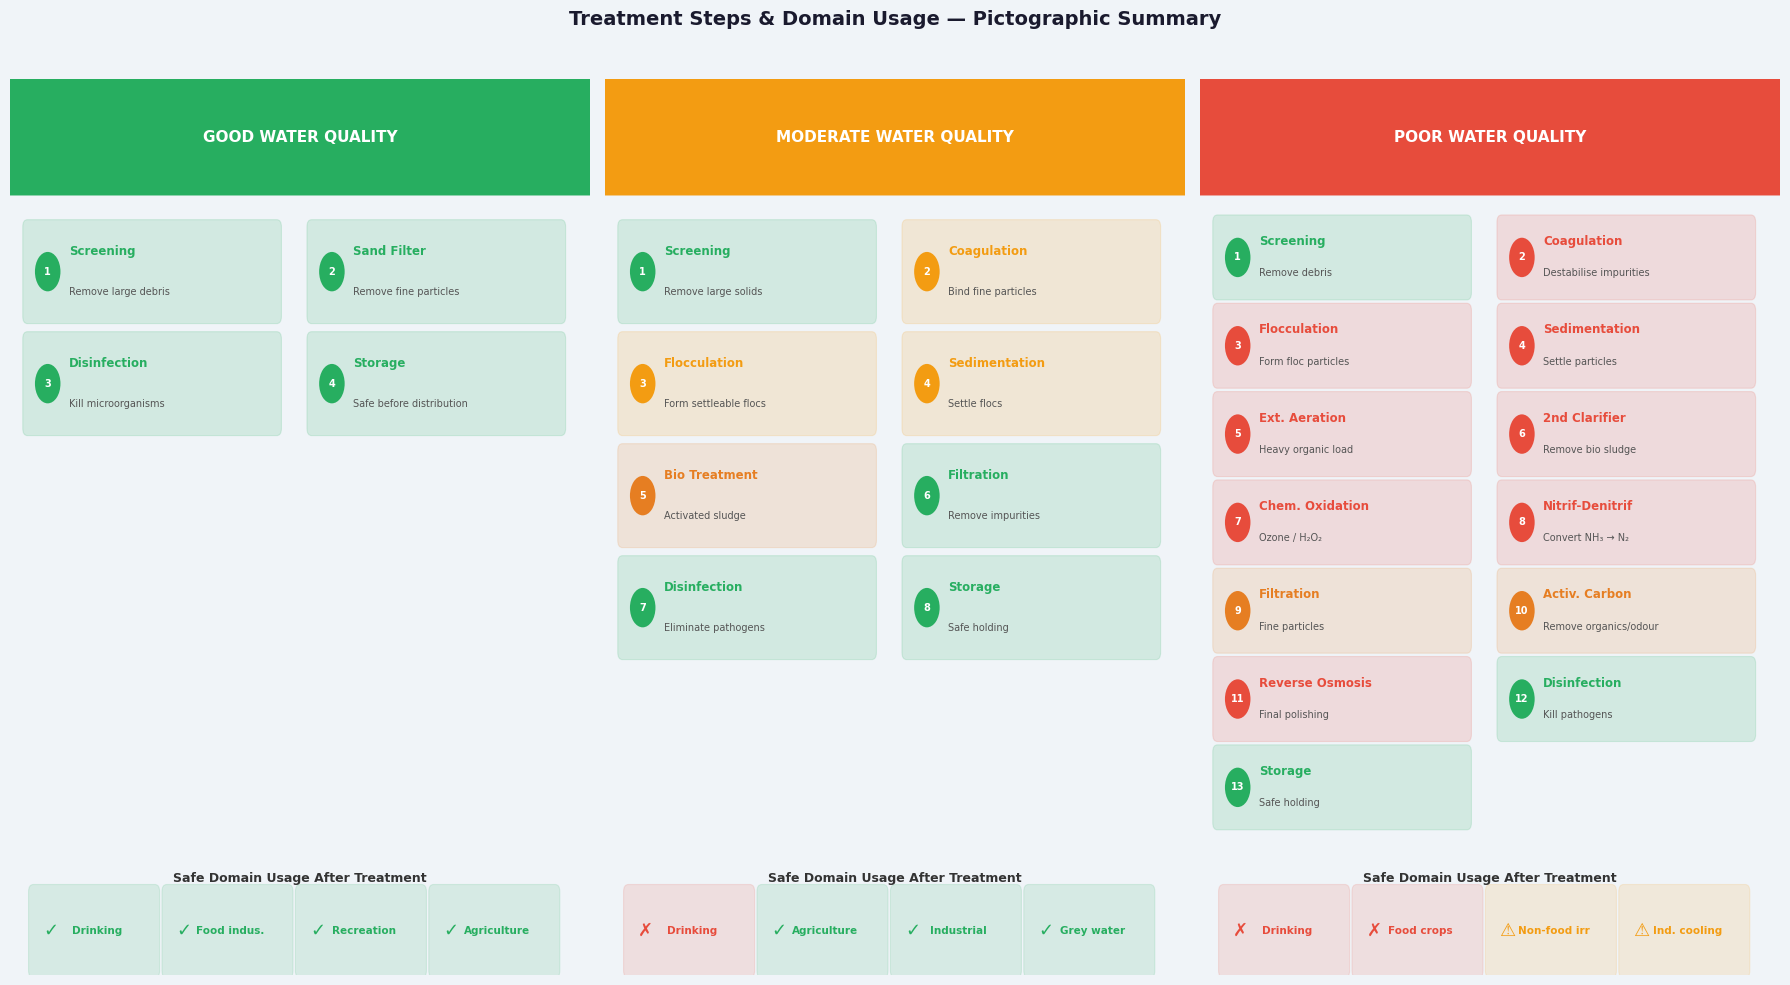

In [36]:
"""## Visualisation 4 — Treatment Steps & Domain Usage Pictograph"""

quality_colors = {'Good': '#27ae60', 'Moderate': '#f39c12', 'Poor': '#e74c3c'}

def draw_treatment_pictograph(ax, quality_class):
    ax.set_facecolor('#ffffff')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    cls_color = quality_colors[quality_class]

    # Title band
    ax.add_patch(FancyBboxPatch((0, 8.8), 10, 1.1, boxstyle='round,pad=0.1',
                                facecolor=cls_color, edgecolor='none'))
    ax.text(5, 9.35, f'{quality_class.upper()} WATER QUALITY',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    steps_map = {
        'Good': [
            ('Screening',    '#27ae60', 'Remove large debris'),
            ('Sand Filter',  '#27ae60', 'Remove fine particles'),
            ('Disinfection', '#27ae60', 'Kill microorganisms'),
            ('Storage',      '#27ae60', 'Safe before distribution'),
        ],
        'Moderate': [
            ('Screening',       '#27ae60', 'Remove large solids'),
            ('Coagulation',     '#f39c12', 'Bind fine particles'),
            ('Flocculation',    '#f39c12', 'Form settleable flocs'),
            ('Sedimentation',   '#f39c12', 'Settle flocs'),
            ('Bio Treatment',   '#e67e22', 'Activated sludge'),
            ('Filtration',      '#27ae60', 'Remove impurities'),
            ('Disinfection',    '#27ae60', 'Eliminate pathogens'),
            ('Storage',         '#27ae60', 'Safe holding'),
        ],
        'Poor': [
            ('Screening',       '#27ae60', 'Remove debris'),
            ('Coagulation',     '#e74c3c', 'Destabilise impurities'),
            ('Flocculation',    '#e74c3c', 'Form floc particles'),
            ('Sedimentation',   '#e74c3c', 'Settle particles'),
            ('Ext. Aeration',   '#e74c3c', 'Heavy organic load'),
            ('2nd Clarifier',   '#e74c3c', 'Remove bio sludge'),
            ('Chem. Oxidation', '#e74c3c', 'Ozone / H₂O₂'),
            ('Nitrif-Denitrif', '#e74c3c', 'Convert NH₃ → N₂'),
            ('Filtration',      '#e67e22', 'Fine particles'),
            ('Activ. Carbon',   '#e67e22', 'Remove organics/odour'),
            ('Reverse Osmosis', '#e74c3c', 'Final polishing'),
            ('Disinfection',    '#27ae60', 'Kill pathogens'),
            ('Storage',         '#27ae60', 'Safe holding'),
        ],
    }

    steps    = steps_map[quality_class]
    cols_s   = 2
    rows_s   = -(-len(steps) // cols_s)
    start_y  = 8.6
    cell_h   = min(1.25, (start_y - 1.7) / rows_s)

    for idx, (name, col, desc) in enumerate(steps):
        r = idx // cols_s
        c = idx  % cols_s
        x = 0.3 + c * 4.9
        y = start_y - r * cell_h - cell_h

        ax.add_patch(FancyBboxPatch((x, y), 4.3, cell_h * 0.80,
                                    boxstyle='round,pad=0.08',
                                    facecolor=col, alpha=0.15,
                                    edgecolor=col, linewidth=0.8))
        ax.add_patch(Circle((x + 0.35, y + cell_h * 0.40), 0.22,
                             facecolor=col, edgecolor='none'))
        ax.text(x + 0.35, y + cell_h * 0.40, str(idx + 1),
                ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        ax.text(x + 0.72, y + cell_h * 0.58, name,
                ha='left', va='center', fontsize=8.5, fontweight='bold', color=col)
        ax.text(x + 0.72, y + cell_h * 0.22, desc,
                ha='left', va='center', fontsize=7, color='#555555')

    # Domain usage cards at bottom
    ax.text(5, 1.08, 'Safe Domain Usage After Treatment',
            ha='center', va='center', fontsize=9, fontweight='bold', color='#333333')

    domains_map = {
        'Good':     [('Drinking',    '✓', '#27ae60'),
                     ('Food indus.', '✓', '#27ae60'),
                     ('Recreation',  '✓', '#27ae60'),
                     ('Agriculture', '✓', '#27ae60')],
        'Moderate': [('Drinking',    '✗', '#e74c3c'),
                     ('Agriculture', '✓', '#27ae60'),
                     ('Industrial',  '✓', '#27ae60'),
                     ('Grey water',  '✓', '#27ae60')],
        'Poor':     [('Drinking',    '✗', '#e74c3c'),
                     ('Food crops',  '✗', '#e74c3c'),
                     ('Non-food irr','⚠', '#f39c12'),
                     ('Ind. cooling','⚠', '#f39c12')],
    }

    for di, (dlabel, dmark, dcol) in enumerate(domains_map[quality_class]):
        dx = 0.4 + di * 2.3
        dy = 0.05
        ax.add_patch(FancyBboxPatch((dx, dy), 2.1, 0.88,
                                    boxstyle='round,pad=0.08',
                                    facecolor=dcol, alpha=0.13,
                                    edgecolor=dcol, linewidth=0.8))
        ax.text(dx + 0.30, dy + 0.44, dmark,
                ha='center', va='center', fontsize=13, color=dcol, fontweight='bold')
        ax.text(dx + 1.10, dy + 0.44, dlabel,
                ha='center', va='center', fontsize=7.5, color=dcol, fontweight='bold')


fig3, axes3 = plt.subplots(1, 3, figsize=(18, 10))
fig3.patch.set_facecolor('#f0f4f8')
fig3.suptitle('Treatment Steps & Domain Usage — Pictographic Summary',
              fontsize=14, fontweight='bold', color='#1a1a2e', y=0.98)

for ax3, cls in zip(axes3, ['Good', 'Moderate', 'Poor']):
    draw_treatment_pictograph(ax3, cls)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('viz3_treatment_domain_pictograph.', dpi=150, bbox_inches='tight', facecolor='#f0f4f8')
plt.show()

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Re-defining X, y, and train/test splits for self-contained execution
# Ensure 'WTP_Process', 'Water_Quality', 'WQI', and 'Predicted_Quality' are dropped as they contain string data or are targets/derived targets
X = df_final.drop(['WQI', 'Water_Quality', 'WTP_Process', 'Predicted_Quality'], axis=1)
y = df_final['Water_Quality']

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Random Forest Model (re-calculating for comparison)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

# Decision Tree Model
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)

y_pred_dtc = dtc_model.predict(X_test)
dtc_accuracy = accuracy_score(y_test, y_pred_dtc)

print("Decision Tree Accuracy:", dtc_accuracy)
print(classification_report(y_test, y_pred_dtc))

# Difference in accuracy
accuracy_difference = abs(rf_accuracy - dtc_accuracy)
print(f"\nDifference in Accuracy (Random Forest vs Decision Tree): {accuracy_difference:.4f}")

Random Forest Accuracy: 0.9350180505415162
Decision Tree Accuracy: 0.8772563176895307
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        89
           1       0.88      0.92      0.90       165
           2       0.79      0.83      0.81        23

    accuracy                           0.88       277
   macro avg       0.85      0.85      0.85       277
weighted avg       0.88      0.88      0.88       277


Difference in Accuracy (Random Forest vs Decision Tree): 0.0578
